In [1]:
import glob
import matplotlib.pyplot as plt
import numpy as np
import os
from plot_progress import gather_metrics
from parse_levels import find_levels_in_configs, find_levels_in_configs_glob
import pandas as pd
import matplotlib.ticker as ticker
import re

In [2]:
def pass_at_k(n, c, k):
    """
    Calculate the pass@k metric.

    Args:
        n (int): Total number of samples.
        c (int): Number of correct samples.
        k (int): The k value in pass@k.

    Returns:
        float: The pass@k value, representing the probability of having at least one correct sample
               in k attempts.
    """
    # If the number of incorrect samples is less than k, return 1.0 (100% success rate)
    if n - c < k:
        return 1.0
    # Calculate the probability of failure for all k attempts and subtract from 1
    return 1.0 - np.prod(1.0 - k / np.arange(n - c + 1, n + 1))

In [4]:
workspace_base_path = lambda item: os.path.join('/checkpoint/maui/zhaobc/scientist/workspace', item)


In [5]:
ori_results = find_levels_in_configs_glob(
    [
        '/checkpoint/maui/zhaobc/scientist/workspace/record_*_20250416_*',
        # '/checkpoint/maui/zhaobc/scientist/workspace/record_*_20250405_*'
        # '/checkpoint/maui/zhaobc/scientist/workspace/record_1[2-8]_20250412_*',
        #  '/checkpoint/maui/zhaobc/scientist/workspace/record_*_20250408_*',
        # '/checkpoint/maui/zhaobc/scientist/workspace/record_*_20250405_*'
        # '/checkpoint/maui/zhaobc/scientist/workspace/record_1[2-8]_20250409_*',
    ]
)

Found 73 directories


In [6]:
from parse_levels import filter_folder_info

In [7]:
folder_info = ori_results

In [8]:
folder_info

{'record_15_20250416_093754_1992447-1992432-4': {'record': 15,
  'levels': [1],
  'ideator': 'dummy',
  'knowledge_coder': False,
  'runner': 'bon',
  'model': 'o3-mini',
  'n_initial_hypotheses': None,
  'n_hypotheses': 50,
  'debug_prob': None},
 'record_1_20250416_094531_1992836-1992626-0': {'record': 1,
  'levels': [12],
  'ideator': 'dummy',
  'knowledge_coder': False,
  'runner': 'bon',
  'model': 'deepseek-r1',
  'n_initial_hypotheses': None,
  'n_hypotheses': 50,
  'debug_prob': None},
 'record_8_20250416_094432_1992660-1992603-7': {'record': 8,
  'levels': [1],
  'ideator': 'dummy',
  'knowledge_coder': False,
  'runner': 'bon',
  'model': 'o3-mini',
  'n_initial_hypotheses': None,
  'n_hypotheses': 50,
  'debug_prob': None},
 'record_17_20250416_093713_1992413-1992406-6': {'record': 17,
  'levels': [12],
  'ideator': 'dummy',
  'knowledge_coder': False,
  'runner': 'bon',
  'model': 'deepseek-r1',
  'n_initial_hypotheses': None,
  'n_hypotheses': 50,
  'debug_prob': None},
 '

In [9]:
r1_flat = filter_folder_info(folder_info, 
                              [('levels', 1), 
                              #  ('runner', 'aide'), 
                              #  ('ideator', 'dummy'), 
                              ('model', 'deepseek-r1'),
                               ('n_hypotheses', 50),
                               ]
                            #    ('knowledge_coder', 'no_knowledge')]
                               )
o3_flat = filter_folder_info(folder_info, 
                              [('levels', 1), 
                              #  ('runner', 'aide'), 
                              #  ('ideator', 'dummy'), 
                              ('model', 'o3-mini'),
                               ('n_hypotheses', 50),
                               ]
                            #    ('knowledge_coder', 'no_knowledge')]
                               )


In [10]:
search_results = find_levels_in_configs_glob(
    [
        '/checkpoint/maui/zhaobc/scientist/workspace/record_*_20250408_*',
        # '/checkpoint/maui/zhaobc/scientist/workspace/record_*_20250405_*'
        '/checkpoint/maui/zhaobc/scientist/workspace/record_1[2-8]_20250409_*',
    ]
)

Found 73 directories


In [11]:
search_results

{'record_9_20250408_155412_1747704-1747695-8': {'record': 9,
  'levels': [1],
  'ideator': 'dummy',
  'knowledge_coder': False,
  'runner': 'aide',
  'model': 'o3-mini',
  'n_initial_hypotheses': 1,
  'n_hypotheses': 1,
  'debug_prob': 1.0},
 'record_1_20250408_155151_1747652-1747651-0': {'record': 1,
  'levels': [1],
  'ideator': 'dummy',
  'knowledge_coder': False,
  'runner': 'bon',
  'model': 'deepseek-r1',
  'n_initial_hypotheses': None,
  'n_hypotheses': 3,
  'debug_prob': None},
 'record_6_20250408_155217_1747668-1747662-5': {'record': 6,
  'levels': [1],
  'ideator': 'dummy',
  'knowledge_coder': False,
  'runner': 'bon',
  'model': 'o3-mini',
  'n_initial_hypotheses': None,
  'n_hypotheses': 3,
  'debug_prob': None},
 'record_11_20250408_155217_1747662-1747662-10': {'record': 11,
  'levels': [1],
  'ideator': 'dummy',
  'knowledge_coder': False,
  'runner': 'bon',
  'model': 'o3-mini',
  'n_initial_hypotheses': None,
  'n_hypotheses': 3,
  'debug_prob': None},
 'record_1_20250

In [29]:
r1_bon = filter_folder_info(search_results, 
                              [('levels', 1), 
                              ('runner', 'bon'), 
                              #  ('ideator', 'dummy'), 
                              ('model', 'deepseek-r1'),
                            #    ('n_hypotheses', 50),
                               ]
                            #    ('knowledge_coder', 'no_knowledge')]
                               )
r1_aide = filter_folder_info(search_results, 
                              [('levels', 1), 
                              ('runner', 'aide'), 
                              #  ('ideator', 'dummy'), 
                              ('model', 'deepseek-r1'),
                               ]
                            )

In [30]:
len(r1_bon), len(r1_aide)

(18, 18)

In [31]:
def process_metrics(record):
    for k, v in record.items():
        metrics = gather_metrics(
            workspace_base_path(k),
            metrics=['val_loss', 'train_time'],
            workspace_template_path=os.path.join(
                'workspace_templates', 
                'nanogpt_speedrun', 
                f"record_{v['record']}"
            )
        )
        metrics.loc[metrics['val_loss'] >= 3.29, 'train_time'] = np.nan
        record[k]['metrics'] = metrics
    return record


In [32]:
r1_flat_search = process_metrics(r1_flat)
# o3_flat_search = process_metrics(o3_flat)
r1_bon_search = process_metrics(r1_bon)
r1_aide_search = process_metrics(r1_aide)

In [33]:
def convert_to_dict(record):
    results = {}
    for k, v in record.items():
        # record_num = int(k.split('-')[-1])
        ## the +1 here is because the process is 0-indexed but record number is 1-indexed
        # results[record_num + 1] = v['metrics']['train_time'].min()
        # record_num = k.split('_2025')[0].split('_')[-1]
        pattern = r"^record_(\d+)_"
        match = re.match(pattern, k)
        record_num = int(match.group(1))
        # results[record_num] = v['metrics']['train_time'].min()
        results[record_num] = v['metrics']['train_time'].tolist()
    return results

r1_flat_search_result = convert_to_dict(r1_flat_search)
# o3_flat_search_result = convert_to_dict(o3_flat_search)
r1_bon_search_result = convert_to_dict(r1_bon_search)
r1_aide_search_result = convert_to_dict(r1_aide_search)
# r1_bon_results = convert_to_dict(r1_bon_dummy_no_knowledge_l1)
# r1_aide_results = convert_to_dict(r1_aide_dummy_no_knowledge_l1)
# r1_aide_l12_results = convert_to_dict(r1_aide_dummy_no_knowledge_l12)
# # o3_bon_results = convert_to_dict(o3_bon_dummy_no_knowledge_l1)
# o3_aide_results = convert_to_dict(o3_aide_dummy_no_knowledge_l1)
# o3_aide_l12_results = convert_to_dict(o3_aide_dummy_no_knowledge_l12)

In [34]:

human_train_time_dict = {
    1: 2936369,
    2: 2304681,
    3: 1282839,
    4: 1301740,
    5: 949528,
    6: 766259,
    7: 773072,
    8: 662205,
    9: 505531,
    10: 477150,
    11: 442985,
    12: 317839,
    13: 289805,
    14: 273107,
    15: 241463,
    16: 232971,
    17: 220374,
    18: 211840,
    19: 199442
}

In [35]:
def compute_gap_in_percentage_list(
        model_time, 
        human_time=human_train_time_dict, 
    ):
    gaps = {}
    for k, v in human_time.items():
        if (k + 1) not in human_time:
            continue
        gaps[k] = v - human_time[k+1]
    
    recovered_times = {}
    for k, vs in model_time.items():
        recovered_times[k] = []
        for v in vs:
            recovered_time = human_time[k] - v
            recovered_times[k].append(recovered_time)

    recovered_gap_in_percentage = {}
    for k, vs in recovered_times.items():
        if (k + 1) not in gaps:
            continue
        recovered_gap_in_percentage[k] = []
        for v in vs:
            recovered_gap_in_percentage[k].append(v / gaps[k] if gaps[k] > 0 else 0)
        recovered_gap_in_percentage[k] = np.array(recovered_gap_in_percentage[k])
        # replace nan with 0
        recovered_gap_in_percentage[k][np.isnan(recovered_gap_in_percentage[k])] = 0

    return recovered_gap_in_percentage



In [36]:
# r1_bon_gap_in_percentage = compute_gap_in_percentage(r1_bon_results)
# r1_aide_gap_in_percentage = compute_gap_in_percentage(r1_aide_results)
# r1_aide_l12_gap_in_percentage = compute_gap_in_percentage(r1_aide_l12_results)
# # o3_bon_gap_in_percentage = compute_gap_in_percentage(o3_bon_results)
# o3_aide_gap_in_percentage = compute_gap_in_percentage(o3_aide_results)
# o3_aide_l12_gap_in_percentage = compute_gap_in_percentage(o3_aide_l12_results)
r1_flat_search_gap = compute_gap_in_percentage_list(r1_flat_search_result)
# o3_flat_search_gap = compute_gap_in_percentage_list(o3_flat_search_result)
r1_bon_search_gap = compute_gap_in_percentage_list(r1_bon_search_result)
r1_aide_search_gap = compute_gap_in_percentage_list(r1_aide_search_result)


In [37]:
def count_success(gap, threshold_to_win=0.1):
    record_num2win = {}
    for record_num, vs in gap.items():
        win_cnt = 0
        for v in vs:
            if v >= threshold_to_win:
                win_cnt += 1
        record_num2win[record_num] = win_cnt
    return record_num2win

In [38]:
r1_num2win = count_success(r1_flat_search_gap, threshold_to_win=0.3)
# o3_num2win = count_success(o3_flat_search_gap)
r1_bon_num2win = count_success(r1_bon_search_gap, threshold_to_win=0.3)
r1_aide_num2win = count_success(r1_aide_search_gap, threshold_to_win=0.3)


In [39]:
def get_pass_at_k(search_results, num2win):
    res_pass_at_k = {}
    for key, v in num2win.items():
        total_num = len(search_results[key])
        res_pass_at_k[key] = [pass_at_k(total_num, v, k) for k in range(1, total_num+1)]
    return res_pass_at_k

r1_pass_at_k = get_pass_at_k(r1_flat_search_result, r1_num2win)
# o3_pass_at_k = get_pass_at_k(o3_flat_search_result, o3_num2win)
r1_bon_pass_at_k = get_pass_at_k(r1_bon_search_result, r1_bon_num2win)
r1_aide_pass_at_k = get_pass_at_k(r1_aide_search_result, r1_aide_num2win)
# then we can plot the pass@k

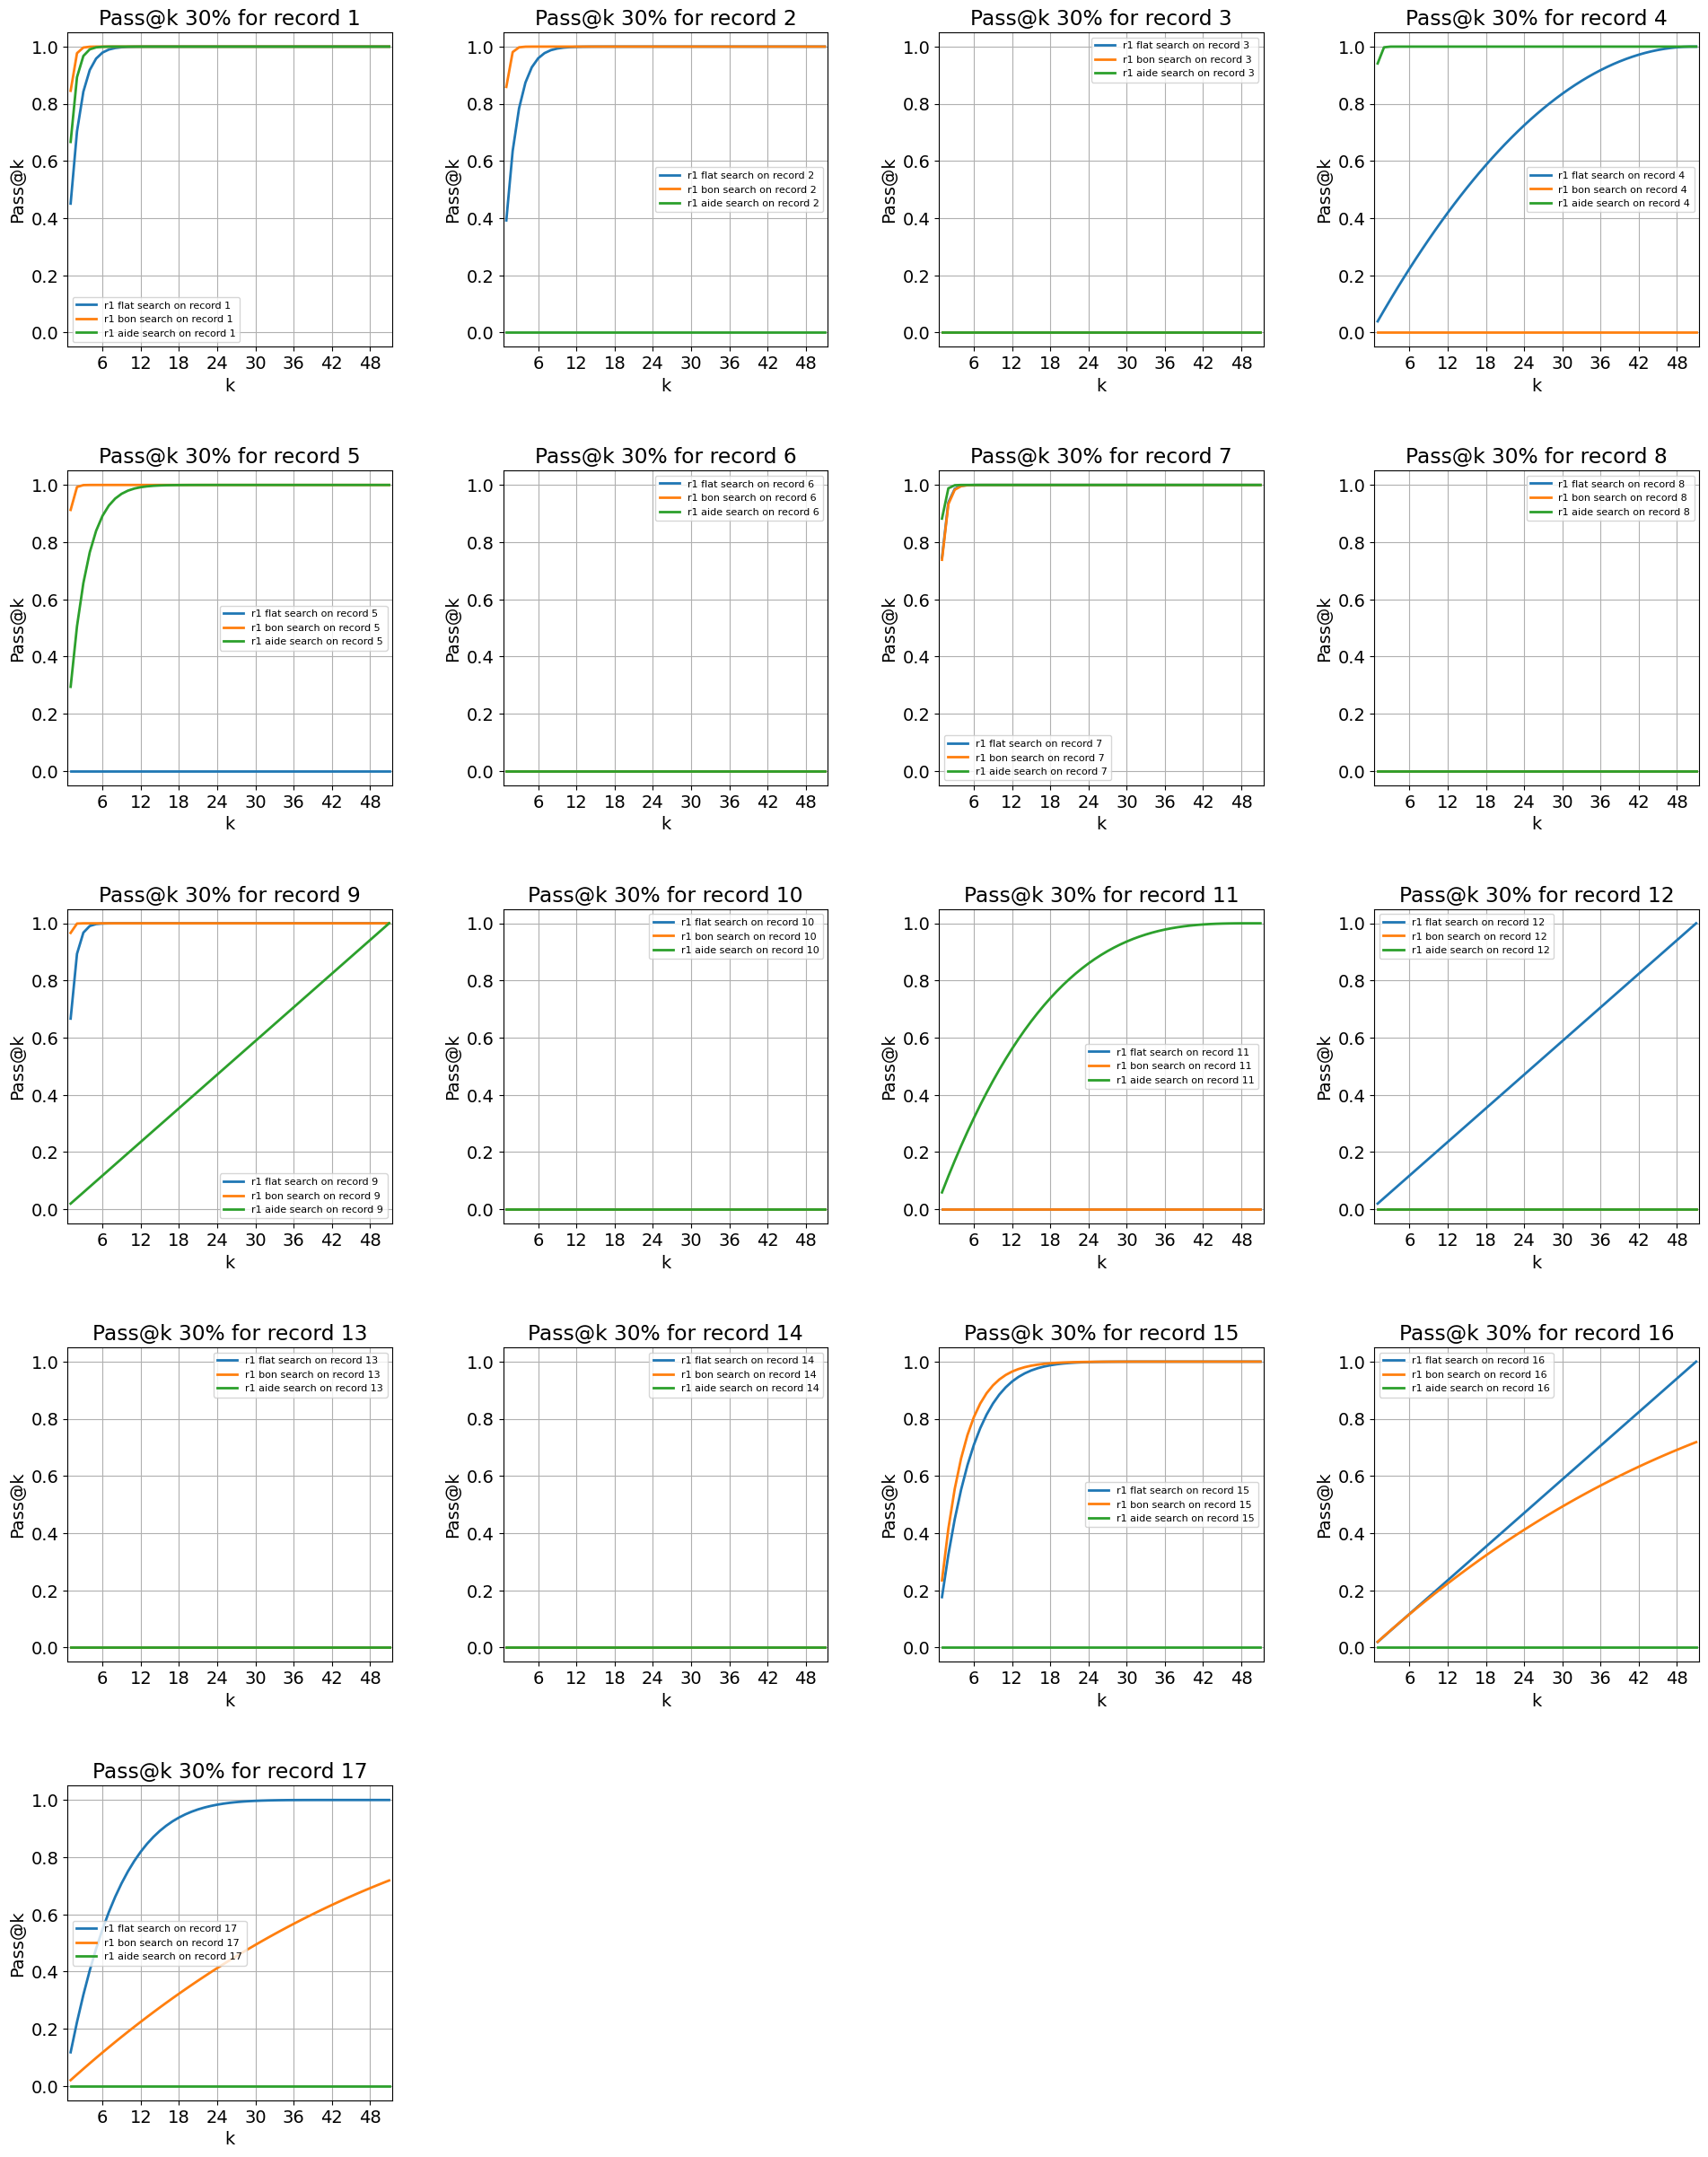

In [49]:
# plot pass@k
keys = sorted(r1_pass_at_k.keys())
# Calculate number of rows and columns for subplots
n_plots = len(keys)
n_cols = 4
n_rows = (n_plots + n_cols - 1) // n_cols
fig, axs = plt.subplots(n_rows, n_cols, figsize=(20, 5*n_rows))
axs = axs.flatten()

for idx, k in enumerate(keys):
    plot_dict_r1 = {idx+1:v for idx, v in enumerate(r1_pass_at_k[k])}
    plot_dict_r1_bon = {idx+1:v for idx, v in enumerate(r1_bon_pass_at_k[k])}
    plot_dict_r1_aide = {idx+1:v for idx, v in enumerate(r1_aide_pass_at_k[k])}
    
    # Convert dictionaries to lists for proper plotting
    x_values = list(plot_dict_r1.keys())
    y_values_r1 = list(plot_dict_r1.values())
    y_values_r1_bon = list(plot_dict_r1_bon.values())
    y_values_r1_aide = list(plot_dict_r1_aide.values())
    # Find the minimum length
    min_len = min(len(y_values_r1), len(y_values_r1_bon), len(y_values_r1_aide))
    
    # Truncate arrays to match min_len
    y_values_r1 = y_values_r1[:min_len]
    y_values_r1_bon = y_values_r1_bon[:min_len]
    y_values_r1_aide = y_values_r1_aide[:min_len]
    # Adjust x_values to match
    x_values = list(range(1, min_len + 1))
    
    axs[idx].plot(x_values, y_values_r1, 
                  label=f"r1 flat search on record {k}", linewidth=2)
    axs[idx].plot(x_values, y_values_r1_bon, 
                  label=f"r1 bon search on record {k}", linewidth=2)
    axs[idx].plot(x_values, y_values_r1_aide, 
                  label=f"r1 aide search on record {k}", linewidth=2)
    
    axs[idx].set_title(f"Pass@k 30% for record {k}")
    axs[idx].set_xlabel("k")
    axs[idx].set_ylabel("Pass@k")
    
    # Move legend to a better position
    axs[idx].legend(loc='best', fontsize=8)
    
    axs[idx].grid(True)
    axs[idx].set_ylim(-.05, 1.05)
    
    # Ensure x-axis uses all values and is properly spaced
    max_k = len(x_values)
    axs[idx].set_xlim(0.5, max_k + 0.5)
    
    # Force integer ticks
    axs[idx].xaxis.set_major_locator(ticker.MaxNLocator(nbins=min(max_k, 10), integer=True))
    
    # Make sure there's enough space for all the data
    axs[idx].margins(x=0.1)

# Hide empty subplots
for idx in range(len(keys), len(axs)):
    axs[idx].set_visible(False)

plt.tight_layout(pad=3.0)
plt.show()